In [2]:
%load_ext autoreload
%autoreload 2

from substrata import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
plot = initializer.ProjectInitializer(path='/mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008')
plot.initialize()

Loading pointcloud from /mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008_dec50M.ply
Loading cameras from /mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008.meta.json and /mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008.cams.xml
Loading markers from /mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008_markers.csv
Loading annotations from /mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008_intercepts.csv


In [27]:
ann = Annotation([-0.329725742,	-36.19788742, -5.783945084])
ann.transform_coords(plot.world_transform)
matches = ann.get_image_matches(plot.cams, pcd=plot.pcd, debug=True)

Cam 0 has pixel match at: 2441, 5216, 7.066338021164584, 0.018752684068401877
Reprojection error: 0.008200508327519689
Cam 1 has pixel match at: 1963, 5362, 6.503210317832434, 0.02088684972842021
Reprojection error: 0.008200508327519689
Cam 2 has pixel match at: 1252, 4620, 6.195905280327661, 0.020427457021083964
Reprojection error: 0.008200508327519689
Cam 3 has pixel match at: 248, 4673, 4.8321280391715735, 0.023202031744951862
Reprojection error: 0.008200508327519689
Cam 4 has pixel match at: 171, 4731, 3.9975678381880604, 0.0227869225137715
Reprojection error: 0.41974476316095904
Cam 5 has pixel match at: 678, 4758, 3.7006421805124172, 0.020629543812516287
Reprojection error: 1.2214387095048498
Cam 6 has pixel match at: 416, 5133, 3.9102488136260933, 0.023203236356634887
Reprojection error: 0.4398872112418775
Cam 7 has pixel match at: 619, 5187, 5.027160548338324, 0.02358969250723074
Reprojection error: 0.008831180366167556
Cam 8 has pixel match at: 1036, 5615, 5.290068265180294, 0

In [4]:
annos = Annotations('/mnt/sdd/tonga_focal/ton_tof/ton_tof_40m/ton_tof_40m_20241008/ton_tof_40m_20241008_topdown_intercepts.csv', 
                    orig_coords_only=True)
annos.transform_coords(plot.world_transform)
missing = 0
for ann in annos:
    match = ann.get_first_image_match(plot.cams, pcd=plot.pcd)
    if match is None:
        #print(ann.id, ann.coords, ann.orig_coords)
        #match = ann.get_image_matches(plot.cams, pcd=plot.pcd, debug=True)
        missing += 1
print(missing, len(plot.annotations))

5 2500


In [9]:
#2397 [ 26.84861285   8.54587852 -40.04508665] [  7.79527395 -33.71733723   2.40201754]
#Cam 4 has pixel match at: 8018, 1104, 4.441951605909616, 0.011662458989839749
#Reprojection error: 0.8756261016968896

ann = plot.annotations.data['2397']
matches = ann.get_image_matches(plot.cams, pcd=plot.pcd)
for match in matches:
    match.show()


TypeError: 'NoneType' object is not iterable

In [3]:
pcd_source = PointCloud('/home/pbongaerts/Downloads/cur_sna_20m_20200303_dec50M.ply')
pcd_target = PointCloud('/home/pbongaerts/Downloads/cur_sna_20m_20231201_dec50M.ply')

In [9]:
pcd_source.get_auto_align_transform(pcd_target, visualize=True)

auto_align: voxel_size=4.3011, allow_scaling=True
Downsampled sizes: src=1027, dst=1256
ICP fitness=0.9050, rmse=1.6004


(array([[-4.52704711e-01, -5.43643218e-01,  1.40255988e-01,
         -9.93023386e+01],
        [-5.49517780e-01,  3.92100770e-01, -2.53866975e-01,
          1.24853771e+02],
        [ 1.15108209e-01, -2.66214732e-01, -6.60334054e-01,
         -2.19247988e+01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]]),
 {'stage': 'icp',
  'fitness': 0.905013750793315,
  'inlier_rmse': 1.6003797243009557,
  'src_down': 1027,
  'dst_down': 1256})

In [4]:
auto_transform = [[-4.52704711e-01, -5.43643218e-01,  1.40255988e-01,
         -9.93023386e+01],
        [-5.49517780e-01,  3.92100770e-01, -2.53866975e-01,
          1.24853771e+02],
        [ 1.15108209e-01, -2.66214732e-01, -6.60334054e-01,
         -2.19247988e+01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]]

In [5]:
pcd_source.apply_transform(auto_transform)

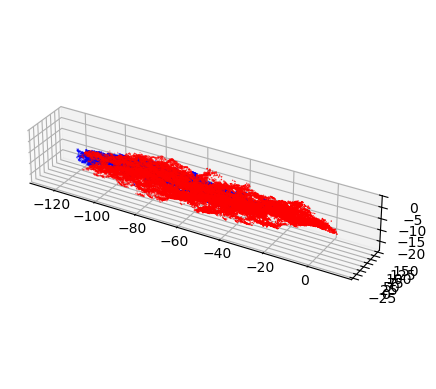

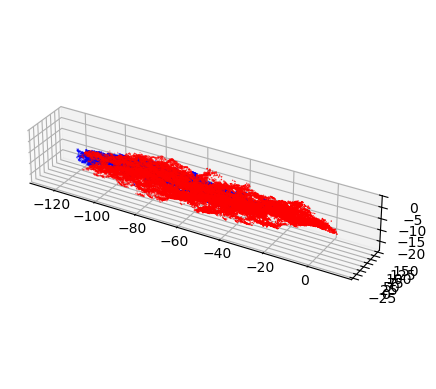

In [12]:
visualizations.plot_compare(pcd_source, pcd_target)

In [2]:
plot = pcd_source.plot_views()

NameError: name 'pcd_source' is not defined

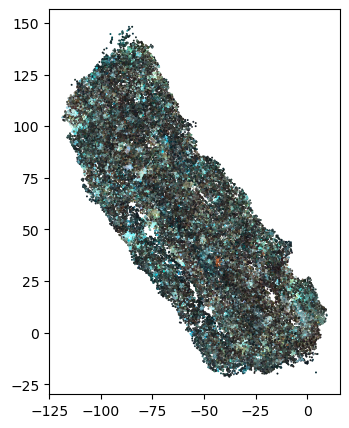

In [17]:
plot = visualizations.plot_2d(pcd_target)